<a href="https://colab.research.google.com/github/mhkbin/AIML-Lab/blob/main/Statement2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 2: The Water Jug Problem (Solved using BFS) Problem Statement: You are given two jugs: Jug A with a capacity of 4 litres, and Jug B with a capacity of 3 litres. Neither jug has any markings on it. Using only the following operations — (i) fill a jug completely, (ii) empty a jug completely, (iii) pour water from one jug into the other until either the first jug is empty or the second jug is full — determine the minimum sequence of steps needed to measure out exactly 2 litres of water in any one jug.

Minimum sequence of steps:

Step 0 : (0, 0)
Step 1 : (0, 3)
Step 2 : (3, 0)
Step 3 : (3, 3)
Step 4 : (4, 2)
Step 5 : (4, 2)


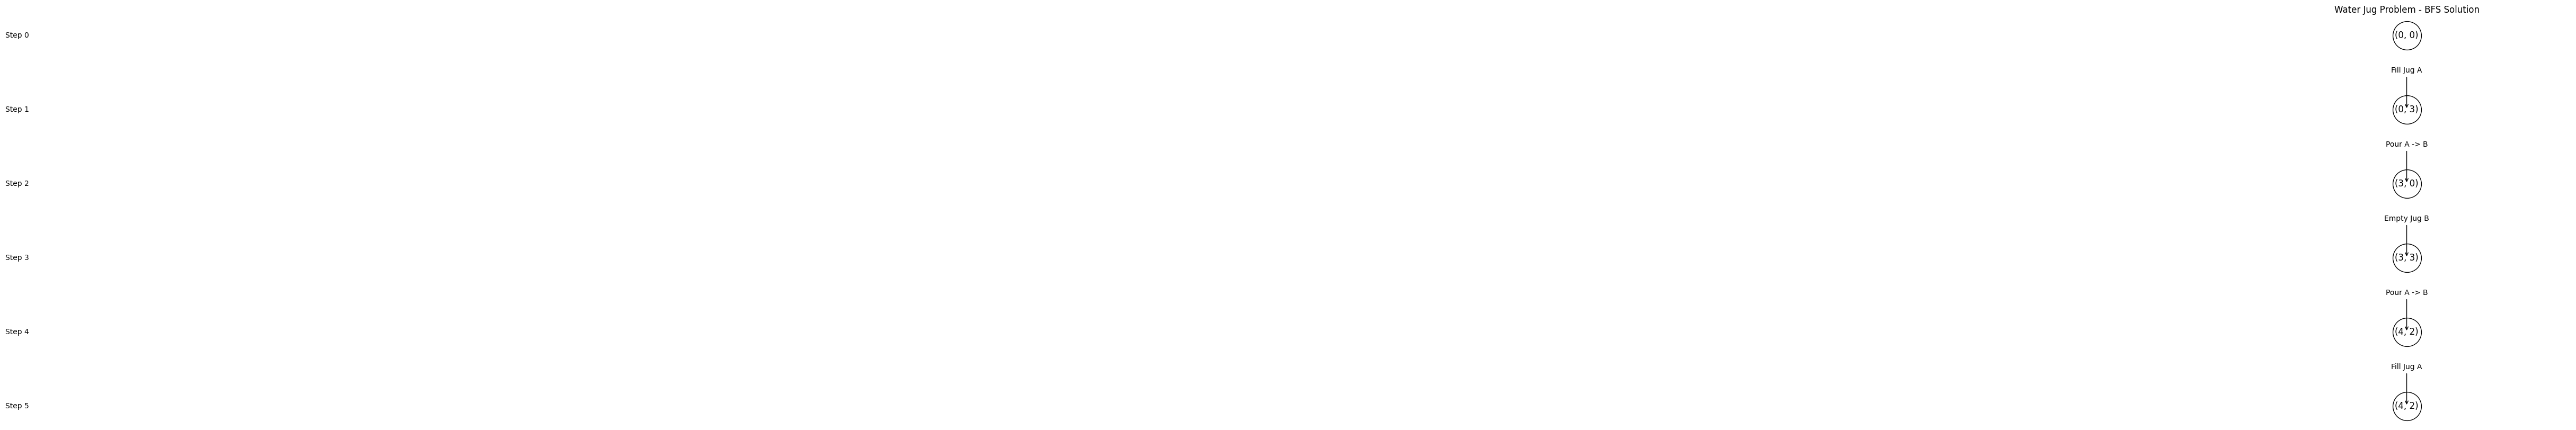

In [ ]:
import matplotlib.pyplot as plt

# Water Jug Problem using BFS

capacity_A = 4
capacity_B = 3

# Starting state
start = (0, 0)

# Queue for BFS
queue = [(start, [])]

# Visited states
visited = [start]

solution = None

while queue:
    (a, b), path = queue.pop(0)

    # Goal condition
    if a == 2 or b == 2:
        solution = path + [(a, b)]
        break

    # 1. Fill Jug A
    new_state = (capacity_A, b)

    if new_state not in visited:
        visited.append(new_state)
        queue.append((new_state, path + [new_state]))

    # 2. Fill Jug B
    new_state = (a, capacity_B)

    if new_state not in visited:
        visited.append(new_state)
        queue.append((new_state, path + [new_state]))

    # 3. Empty Jug A
    new_state = (0, b)

    if new_state not in visited:
        visited.append(new_state)
        queue.append((new_state, path + [new_state]))

    # 4. Empty Jug B
    new_state = (a, 0)

    if new_state not in visited:
        visited.append(new_state)
        queue.append((new_state, path + [new_state]))

    # 5. Pour Jug A into Jug B
    transfer = min(a, capacity_B - b)
    new_state = (a - transfer, b + transfer)

    if new_state not in visited:
        visited.append(new_state)
        queue.append((new_state, path + [new_state]))

    # 6. Pour Jug B into Jug A
    transfer = min(b, capacity_A - a)
    new_state = (a + transfer, b - transfer)

    if new_state not in visited:
        visited.append(new_state)
        queue.append((new_state, path + [new_state]))


# Print the minimum sequence
print("Minimum sequence of steps:\n")

print("Step 0 : (0, 0)")

for i, state in enumerate(solution):
    print("Step", i + 1, ":", state)


# Graphical representation using Matplotlib

states = [(0, 0)] + solution

operations = [
    "Start",
    "Fill Jug A",
    "Pour A -> B",
    "Empty Jug B",
    "Pour A -> B",
    "Fill Jug A",
    "Pour A -> B"
]

plt.figure(figsize=(8, 10))

# Draw states and arrows
for i, state in enumerate(states):

    x = 0
    y = len(states) - i

    # Draw state
    plt.scatter(
        x, y,
        s=1500,
        facecolors='white',
        edgecolors='black'
    )

    plt.text(
        x, y,
        str(state),
        ha='center',
        va='center',
        fontsize=12
    )

    # Step number
    plt.text(
        x - 0.8, y,
        "Step " + str(i),
        ha='center',
        va='center'
    )

    # Draw arrow and operation
    if i < len(states) - 1:

        plt.annotate(
            operations[i + 1],
            xy=(x, y - 1),
            xytext=(x, y - 0.5),
            ha='center',
            arrowprops=dict(arrowstyle='->')
        )


plt.title("Water Jug Problem - BFS Solution")

plt.axis('off')

plt.show()